In [1]:
# save sub-wise estimates to df in '/Users/mrenke/data/ds-stressrisk/interim_sum_data'
# 1. (risky-)prior-mu
# 2. evidence

# compare to objective prior, does the prior become more accurate?

import arviz as az
import os.path as op
from utils import get_data
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

bids_folder = '/Users/mrenke/data/ds-stressrisk'

model_folder = op.join(bids_folder, 'derivatives', 'cogmodels')
df = get_data().set_index('group', append=True)
group_mapping = df.groupby(['subject', 'group']).size().reset_index(['group']).drop(0, axis=1)

objective_risky_mu = np.log(df.groupby(['subject'])['n_risky'].mean())

n_model = 1
idata= az.from_netcdf(op.join(model_folder, f'model-{n_model}_trace.netcdf'))


/Users/mrenke/mambaforge/envs/behav_fit2_copy/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/behav_fit2_copy/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
risky_prior_mu_post = idata.posterior['risky_prior_mu'].to_dataframe()
risky_prior_mu_post = risky_prior_mu_post.join(group_mapping).set_index('group', append=True)

In [3]:
risky_prior_mu_post

risky_prior_mu
chain draw subject risky_prior_mu_regressors group                
0     0    1       Intercept                 0.0          3.091528
                   session                   0.0          0.093866
                   group                     0.0         -1.070381
                   session:group             0.0          1.290285
           2       Intercept                 0.0          3.409533
...                                                            ...
3     999  59      session:group             0.0          0.470096
           61      Intercept                 0.0          3.523256
                   session                   0.0         -0.276224
                   group                     0.0          0.099664
                   session:group             0.0          0.600884

[800000 rows x 1 columns]

In [6]:
import seaborn as sns
prior_mu_ses1_group0 = risky_prior_mu_post.xs('Intercept', 0, 'risky_prior_mu_regressors')
prior_mu_ses2_group0 = risky_prior_mu_post.xs('Intercept', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('session', 0, 'risky_prior_mu_regressors')
prior_mu_ses1_group1 = risky_prior_mu_post.xs('Intercept', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('group', 0, 'risky_prior_mu_regressors')
prior_mu_ses2_group1 = risky_prior_mu_post.xs('Intercept', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('group', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('session', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('session:group', 0, 'risky_prior_mu_regressors')

prior_mu_ses1_group0 = prior_mu_ses1_group0.xs(0, 0, 'group')
prior_mu_ses2_group0 = prior_mu_ses2_group0.xs(0, 0, 'group')

prior_mu_ses1_group1 = prior_mu_ses1_group1.xs(1, 0, 'group')
prior_mu_ses2_group1 = prior_mu_ses2_group1.xs(1, 0, 'group')
#prior_mu_ses2_group1.join(group_mapping).set_index('group', append=True)



In [27]:
# save subwise_change_risky_prior 
import pandas as pd
df_change_risky_prior_gr0 = (prior_mu_ses2_group0 - prior_mu_ses1_group0).groupby(['subject']).mean()
df_change_risky_prior_gr1 = (prior_mu_ses2_group1 - prior_mu_ses1_group1).groupby(['subject']).mean()
df_change_risky_prior = pd.concat([df_change_risky_prior_gr0, df_change_risky_prior_gr1], axis=0)
df_change_risky_prior.to_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_change_risky_prior.csv')


/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_55459/781850079.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diff_objective_subjective_ses1_group0)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_55459/781850079.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dif

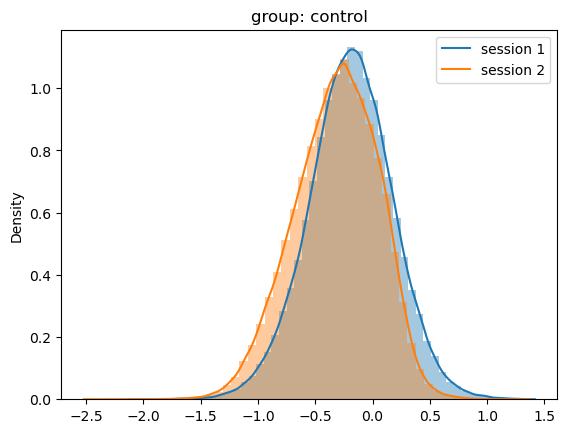

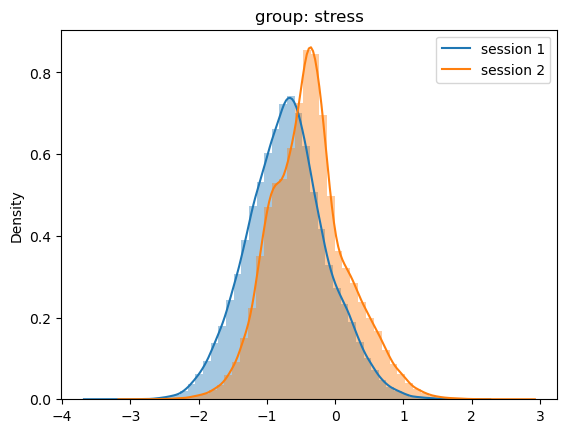

In [17]:
diff_objective_subjective_ses1_group0 = prior_mu_ses1_group0['risky_prior_mu'] - objective_risky_mu
diff_objective_subjective_ses2_group0 = prior_mu_ses2_group0['risky_prior_mu'] - objective_risky_mu
diff_objective_subjective_ses1_group1 = prior_mu_ses1_group1['risky_prior_mu'] - objective_risky_mu
diff_objective_subjective_ses2_group1 = prior_mu_ses2_group1['risky_prior_mu'] - objective_risky_mu
sns.distplot(diff_objective_subjective_ses1_group0)
sns.distplot(diff_objective_subjective_ses2_group0)
plt.title('group: control')
plt.legend(['session 1', 'session 2'])
plt.figure()
sns.distplot(diff_objective_subjective_ses1_group1)
sns.distplot(diff_objective_subjective_ses2_group1)
plt.title('group: stress')
plt.legend(['session 1', 'session 2'])



In [26]:
diff_objective_subjective_ses1_group0 = pd.DataFrame(diff_objective_subjective_ses1_group0)
diff_objective_subjective_ses1_group0['session'] = 1
diff_objective_subjective_ses1_group0['group'] = 0

diff_objective_subjective_ses2_group0 = pd.DataFrame(diff_objective_subjective_ses2_group0)
diff_objective_subjective_ses2_group0['session'] = 2
diff_objective_subjective_ses2_group0['group'] = 0

diff_objective_subjective_ses1_group1 = pd.DataFrame(diff_objective_subjective_ses1_group1)
diff_objective_subjective_ses1_group1['session'] = 1
diff_objective_subjective_ses1_group1['group'] = 1

diff_objective_subjective_ses2_group1 = pd.DataFrame(diff_objective_subjective_ses2_group1)
diff_objective_subjective_ses2_group1['session'] = 2
diff_objective_subjective_ses2_group1['group'] = 1

diff_objective_subjective_group1 = pd.concat([diff_objective_subjective_ses2_group1.set_index(['group','session'], append=True), diff_objective_subjective_ses1_group1.set_index(['group','session'], append=True)],axis=0)
diff_objective_subjective_group0 = pd.concat([diff_objective_subjective_ses2_group0.set_index(['group','session'], append=True), diff_objective_subjective_ses1_group0.set_index(['group','session'], append=True)],axis=0)
diff_objective_subjective = pd.concat([diff_objective_subjective_group0 , diff_objective_subjective_group1],axis=0)


In [31]:
diff_objective_subjective

0
chain draw subject group session          
0     0    1       0     2       -0.186489
           2       0     2       -0.221172
           5       0     2       -0.162468
           9       0     2       -0.507730
           10      0     2        0.044556
...                                    ...
3     999  51      1     1       -0.923225
           52      1     1        0.127031
           54      1     1       -1.273268
           57      1     1       -0.980771
           58      1     1       -1.241797

[400000 rows x 1 columns]

In [25]:
diff_objective_subjective_ses2_group1_['session'] = 2
diff_objective_subjective_ses2_group1_

0  session
chain draw subject                   
0     0    3       -0.394926        2
           4       -0.986185        2
           13      -1.115597        2
           14      -0.238862        2
           18      -1.314464        2
...                      ...      ...
3     999  51      -0.129675        2
           52       0.482447        2
           54      -0.461173        2
           57      -0.563342        2
           58      -0.982006        2

[100000 rows x 2 columns]

In [11]:
pd.concat(diff_objective_subjective_ses1_group0, diff_objective_subjective_ses2_group0], axis=0)


chain  draw  subject
0      0     1         -0.186489
             2         -0.221172
             5         -0.162468
             9         -0.507730
             10         0.044556
                          ...   
3      999   50        -0.659456
             53        -0.438059
             55        -0.338066
             59        -0.280771
             61        -0.248309
Length: 100000, dtype: float64

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_55459/547379540.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diff_of_diff_group0)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_55459/547379540.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diff_of_diff_group1)


<AxesSubplot: ylabel='Density'>

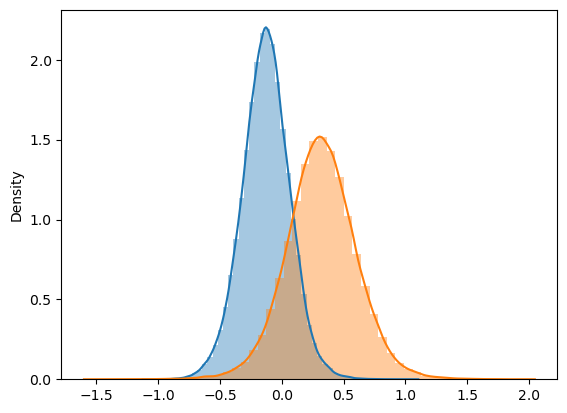

In [9]:
diff_of_diff_group0 = diff_objective_subjective_ses2_group0 - diff_objective_subjective_ses1_group0
diff_of_diff_group1 = diff_objective_subjective_ses2_group1 - diff_objective_subjective_ses1_group1


sns.distplot(diff_of_diff_group0)
sns.distplot(diff_of_diff_group1)
# diff_of_diff = diff_of_diff.groupby(['chain', 'draw']).mean()
# sns.distplot(diff_of_diff)

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_55459/3963165742.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diff_of_diff_group0.groupby(['chain', 'draw']).mean() - diff_of_diff_group1.groupby(['chain', 'draw']).mean())


<AxesSubplot: ylabel='Density'>

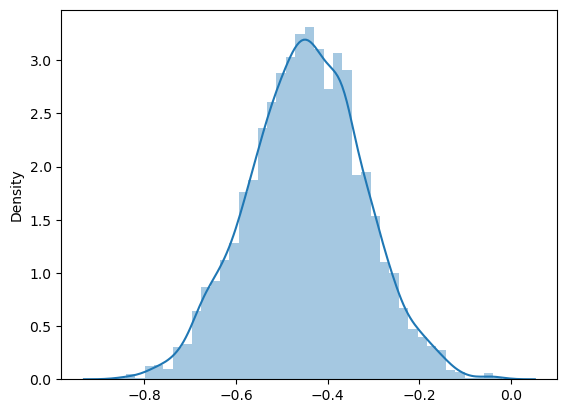

In [10]:
sns.distplot(diff_of_diff_group0.groupby(['chain', 'draw']).mean() - diff_of_diff_group1.groupby(['chain', 'draw']).mean())

In [36]:
final_diff = diff_of_diff_group0.groupby(['chain', 'draw']).mean() - diff_of_diff_group1.groupby(['chain', 'draw']).mean()

(final_diff > 0.0).mean()

0.0

/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/seaborn/axisgrid.py:848: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/seaborn/axisgrid.py:848: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*pl

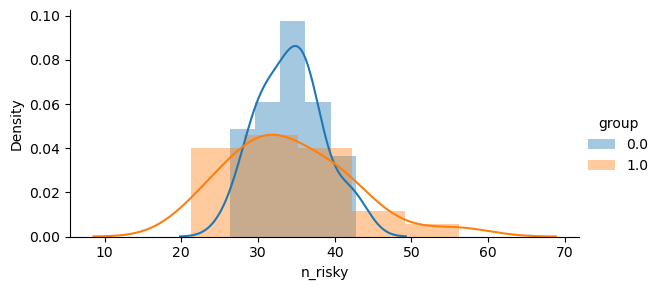

In [22]:
fac = sns.FacetGrid(df.groupby(['subject', 'group'])[['n_risky']].mean().reset_index(), hue='group', aspect=2.)

fac.map(sns.distplot, 'n_risky')
fac.add_legend()

In [6]:
session2 = risky_prior_mu_post.xs('Intercept', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('session', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('Intercept', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('group', 0, 'risky_prior_mu_regressors')

risky_prior_mu
chain draw subject                
0     0    1              6.220962
           2              6.430643
           3              6.236626
           4              6.026185
           5              6.338274
...                            ...
3     999  55             7.395538
           57             4.854034
           58             5.524493
           59             5.744794
           61             5.855991

[200000 rows x 1 columns]

In [38]:
n1_evidence_sd = idata.posterior['n1_evidence_sd'].to_dataframe()
n1_evidence_sd = n1_evidence_sd.join(group_mapping).set_index('group', append=True)

n1_esmu_ses1_group0 = n1_evidence_sd.xs('Intercept', 0, 'n1_evidence_sd_regressors')
n1_esmu_ses2_group0 = n1_evidence_sd.xs('Intercept', 0, 'n1_evidence_sd_regressors') + n1_evidence_sd.xs('session', 0, 'n1_evidence_sd_regressors')
n1_esmu_ses1_group1 = n1_evidence_sd.xs('Intercept', 0, 'n1_evidence_sd_regressors') + n1_evidence_sd.xs('group', 0, 'n1_evidence_sd_regressors')
n1_esmu_ses2_group1 = n1_evidence_sd.xs('Intercept', 0, 'n1_evidence_sd_regressors') + n1_evidence_sd.xs('group', 0, 'n1_evidence_sd_regressors') + n1_evidence_sd.xs('session', 0, 'n1_evidence_sd_regressors') + n1_evidence_sd.xs('session:group', 0, 'n1_evidence_sd_regressors')

n1_esmu_ses1_group0 = n1_esmu_ses1_group0.xs(0, 0, 'group')
n1_esmu_ses2_group0 = n1_esmu_ses2_group0.xs(0, 0, 'group')
n1_esmu_ses1_group1 = n1_esmu_ses1_group1.xs(1, 0, 'group')
n1_esmu_ses2_group1 = n1_esmu_ses2_group1.xs(1, 0, 'group')
n1_esmu_ses1_group0['session'] = int(1)
n1_esmu_ses2_group0['session'] = int(2)
n1_esmu_ses1_group1['session'] = int(1)
n1_esmu_ses2_group1['session'] = int(2)

df_n1_esmu = pd.concat([n1_esmu_ses1_group0.groupby(['subject']).mean(), n1_esmu_ses2_group0.groupby(['subject']).mean(), n1_esmu_ses1_group1.groupby(['subject']).mean(), n1_esmu_ses2_group1.groupby(['subject']).mean()], axis=0)
df_n1_esmu['n1_evidence_sd'] = np.exp(df_n1_esmu['n1_evidence_sd'])
df_n1_esmu['session'] = df_n1_esmu['session'].astype(int)

df_n1_esmu.to_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_seswise_n1_evidence_sd.csv')



/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_83082/604848094.py:10: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  n1_esmu_ses1_group0['session'] = np.int(1)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_83082/604848094.py:11: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review you

In [48]:
n2_evidence_sd = idata.posterior['n2_evidence_sd'].to_dataframe()
n2_evidence_sd = n2_evidence_sd.join(group_mapping).set_index('group', append=True)

n2_esmu_ses1_group0 = n2_evidence_sd.xs('Intercept', 0, 'n2_evidence_sd_regressors')
n2_esmu_ses2_group0 = n2_evidence_sd.xs('Intercept', 0, 'n2_evidence_sd_regressors') + n2_evidence_sd.xs('session', 0, 'n2_evidence_sd_regressors')
n2_esmu_ses1_group1 = n2_evidence_sd.xs('Intercept', 0, 'n2_evidence_sd_regressors') + n2_evidence_sd.xs('group', 0, 'n2_evidence_sd_regressors')
n2_esmu_ses2_group1 = n2_evidence_sd.xs('Intercept', 0, 'n2_evidence_sd_regressors') + n2_evidence_sd.xs('group', 0, 'n2_evidence_sd_regressors') + n2_evidence_sd.xs('session', 0, 'n2_evidence_sd_regressors') + n2_evidence_sd.xs('session:group', 0, 'n2_evidence_sd_regressors')

n2_esmu_ses1_group0 = n2_esmu_ses1_group0.xs(0, 0, 'group')
n2_esmu_ses2_group0 = n2_esmu_ses2_group0.xs(0, 0, 'group')
n2_esmu_ses1_group1 = n2_esmu_ses1_group1.xs(1, 0, 'group')
n2_esmu_ses2_group1 = n2_esmu_ses2_group1.xs(1, 0, 'group')
n2_esmu_ses1_group0['session'] = int(1)
n2_esmu_ses2_group0['session'] = int(2)
n2_esmu_ses1_group1['session'] = int(1)
n2_esmu_ses2_group1['session'] = int(2)

df_n2_esmu = pd.concat([n2_esmu_ses1_group0.groupby(['subject']).mean(), n2_esmu_ses2_group0.groupby(['subject']).mean(), n2_esmu_ses1_group1.groupby(['subject']).mean(), n2_esmu_ses2_group1.groupby(['subject']).mean()], axis=0)
df_n2_esmu['n2_evidence_sd'] = np.exp(df_n2_esmu['n2_evidence_sd'])
df_n2_esmu['session'] = df_n2_esmu['session'].astype(int)

df_n2_esmu.to_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_seswise_n2_evidence_sd.csv')

In [3]:
safe_prior_mu_post = idata.posterior['safe_prior_mu'].to_dataframe()
safe_prior_mu_post = safe_prior_mu_post.join(group_mapping).set_index('group', append=True)

prior_mu_ses1_group0 = safe_prior_mu_post.xs('Intercept', 0, 'safe_prior_mu_regressors')
prior_mu_ses2_group0 = safe_prior_mu_post.xs('Intercept', 0, 'safe_prior_mu_regressors') + safe_prior_mu_post.xs('session', 0, 'safe_prior_mu_regressors')
prior_mu_ses1_group1 = safe_prior_mu_post.xs('Intercept', 0, 'safe_prior_mu_regressors') + safe_prior_mu_post.xs('group', 0, 'safe_prior_mu_regressors')
prior_mu_ses2_group1 = safe_prior_mu_post.xs('Intercept', 0, 'safe_prior_mu_regressors') + safe_prior_mu_post.xs('group', 0, 'safe_prior_mu_regressors') + safe_prior_mu_post.xs('session', 0, 'safe_prior_mu_regressors') + safe_prior_mu_post.xs('session:group', 0, 'safe_prior_mu_regressors')

prior_mu_ses1_group0 = prior_mu_ses1_group0.xs(0, 0, 'group')
prior_mu_ses2_group0 = prior_mu_ses2_group0.xs(0, 0, 'group')

prior_mu_ses1_group1 = prior_mu_ses1_group1.xs(1, 0, 'group')
prior_mu_ses2_group1 = prior_mu_ses2_group1.xs(1, 0, 'group')

df_change_safe_prior_gr0 = (prior_mu_ses2_group0 - prior_mu_ses1_group0).groupby(['subject']).mean()
df_change_safe_prior_gr1 = (prior_mu_ses2_group1 - prior_mu_ses1_group1).groupby(['subject']).mean()
df_change_safe_prior = pd.concat([df_change_safe_prior_gr0, df_change_safe_prior_gr1], axis=0)
df_change_safe_prior.to_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_change_safe_prior.csv')

In [45]:
df_n1_esmu

,n1_evidence_sd,session
subject,,
1,0.324216,1
2,0.315138,1
5,0.330258,1
9,0.326566,1
10,0.316187,1
...,...,...
51,0.312920,2
52,0.266268,2
54,0.317939,2
